# Surrogate modeling


The goal of surrogate modeling methods is to build an inexpensive approximating function for an expensive black-box function. 
Given an analysis that produces an output of interest from an engineering system

\begin{equation*}
y = f(x) 
\end{equation*}
  
* $f(x) : \mathbb{R}^{n} \rightarrow \mathbb{R}$ is some black-box function that is expensive to compute
* Instead of using $f(x)$, we can approximate its value using a surrogate model $f(x) \approx \hat{f}(x) : \mathbb{R}^{n} \rightarrow \mathbb{R}$
* Due to approximation errors, there will be some discrepancy between the true model value and the surrogate model

\begin{equation*}
\epsilon(x) = f(x) - \hat{f}(x)
\end{equation*}

The error $\epsilon(x)$ will vary spatially throughout the domain.
In general, the error will be unknown.
If we knew the error, we could use it to correct the surrogate model!

Additional considerations for surrogate models:

* $\hat{f}(x)$ should be relatively cheap to compute, otherwise we could just use the black-box function
* It can be handy to construct $\hat{f}(x)$ so that it is differentiable, so we can use gradient-based optimization methods, but this is not mandatory
* The error $\epsilon(x)$ is not known, but can be computed at points in the design space 
* Since the black-box function is expensive to evaluate, our goal is to construct the surrogate with as few function evaluations as possible while trying to bound the error
* Some techniques, such as reduced-order modeling, can utilize additional information about how $f(x)$ is computed, for instance, leveraging info from an underlying ODE/PDE. 
* ROMs can provide good accuracy and can encapsulate design-parametrization information, but we won't cover them here

## Surrogate modeling applications and terminology

Surrogate models are used in a number of different applications including

* For design optimization in place of expensive black-box disciplinary analysis
* Within MDO architectures as a drop-in replacement for the response of individual disciplines
* For probabilistic design methods, which often require many function evaluations, such as with Monte Carlo techniques
* Trade-space studies and exploration: exhaustive search techniques can be used

## Steps in surrogate model construction

We will use the following approach to construct a surrogate model:

1. Sampling: Select a set of sample points $x_{i} \in \mathbb{R}^{n}$ for $i = 1,\ldots, N$ at which to sample the function $f_{i} = f(x_{i})$
2. Model form: Select a form of the model $\hat{f}(x)$ that we will use to evaluate the surrogate at $x \ne x_{i}$
3. Fitting or training: Obtain the surrogate model $\hat{f}(x)$ by fitting parameters so that $e(x)$ is minimized in some manner
4. Validation: Assess the predictive performance of the surrogate model against a known set of data

These steps encompass the entire off-line phase of surrogate model construction. After the model has been validated it can be used for prediction in the on-line phase.

### Obtaining the sample set $x_{i}$

There are two broad categories of methods to obtain the sample set:

1. *a priori* sampling strategies that pick all sample locations in advance
2. Adaptive techniques which select new points to add to the sample set based on recently evaluated points
 
Classical surrogate model construction is based on *a priori* construction techniques. These methods do not incorporate any information obtained from the sampling data into where to select the next set of sample points. Adaptive sampling methods try to improve the model accuracy by selecting new sample points based on previous sample points and data. Adaptive sampling methods are an active area of research. These methods can provide superior accuracy but can be more costly.

The field of *design of experiments* (DoE) is dedicated to systematically selecting sample points from within the design space.
Design of experiments are stencils that define where to place $x_{i}$ within the design space to achieve different goals

* DoE methods were first developed for actual experiments, with aleatory uncertainties, so these methods do not assume that $f(x)$ is deterministic
* Design and analysis of computer experiments (DACE) is a specialized field that leveraged ideas from DoE for the specific case where $f(x)$ is deterministic
 
Different types of DoEs:

1. Structured DoEs:
    * Full factorial designs
    * Fractional factorial designs
    * Orthogonal arrays
2. Unstructured DoEs:
    * Latin hypercube designs
    * Quasi-Monte Carlo designs

We'll go into more detail on these later, but for now just assume that we have a set $x_{i}$.

### Surrogate model form

There are many different surrogate model types.
Even with the same set of sample points, different surrogate model types will produce different response

Common surrogate model types include

1. Polynomial response surface
2. Radial basis functions (RBFs)
3. Kriging methods
4. Gaussian processes
5. Artificial neural networks
6. Support vector machines

We will distinguish between models which are linear in their parameters, and models that are nonlinear in their parameters

### Fitting a surrogate model

Surrogate models often take the form where the output is a linear combination of basis functions and weights

\begin{equation*}
\hat{f}(x) = \sum_{i=1}^{m} w_{i} \phi_{i}(x) 
\end{equation*}

Here we have introduced the following

* $w_{i}$ for $i=1,\ldots,m$ are the weights which we will also write as $w \in \mathbb{R}^{m}$
* $\phi_{i}(x)$ for $i=1,\ldots,m$ are some specified basis functions that we know

We have to consider how much data we have vs. how many unknonwns we have. We have $N$ sample points, $x_{i}$ for $i = 1, \ldots N$. And we have $m$ weights $w_{i}$ for $i = 1, \ldots, m$

1. If $N < m$ we have less data than we have weights. This model is called *underdetermined*.
2. If $N = m$ we have exact the same amount of data as we have weights. This model is called an *interpolating* model. The model error should be exactly zero at each data point.
3. If $N > m$ we have more data than we have weights. This model is called *overdetermined* and is a best fit to the sample data.

To determine the model weights, we minimize the error at the sample points.
The error at a sample point $i$ can be evaluated exactly in terms of the weights, basis functions and the function value $f_{i} = f(x_{i})$

\begin{equation*}
\begin{aligned}
e_{i} & = \epsilon(x_{i}) \\
& = f(x_{i}) - \hat{f}(x_{i}) \\
& = f(x_{i}) - \sum_{j=1}^{m} w_{j} \phi_{j}(x_{i}) \\
\end{aligned}
\end{equation*}

This equation can be formed for each sample point $i = 1,\ldots,N$, in which case it is simpler to write the equation as follows

\begin{equation*}
e = f - \Phi w
\end{equation*}

Here we have introduced the following

* $e \in \mathbb{R}^{N}$, $w \in \mathbb{R}^{m}$ and $f \in \mathbb{R}^{N}$ where $f = (f(x_{1}),f(x_{2}),\ldots,f(x_{N}))$
* The matrix $\Phi \in \mathbb{R}^{N \times m}$ is constructed such that each row corresponds to a sample point and each column corresponds to a basis function 
 
The most common approach to minimize the error across all sample points is to minimize the sum-square of the errors with respect to the unknown weights $w$

\begin{equation*}
\min_{w} e^{T}e = \min_{w} (f - \Phi w)^{T}(f - \Phi w)
\end{equation*}

This is an unconstrained optimization problem, so we can use first-order necessary conditions and get the following equation for the weights $w$

\begin{equation*}
\Phi^{T}\Phi w = \Phi^{T} f
\end{equation*}

Note that $\Phi^{T}\Phi$ is an $m \times m$ matrix and $\Phi^{T} f$ is an $m$ vector.

The matrix $\Phi^{T}\Phi$ is positive semi-definite since

\begin{equation*}
v^{T} \Phi^{T} \Phi v = (\Phi v)^{T} \Phi v = z^{T} z \ge 0 
\end{equation*}

where we use $z = \Phi v$. This expression is zero only if $z = 0$ for some non-zero $v$ or if $\Phi v = 0$. This is the case if $\Phi$ is rank deficient, i.e. when the columns of $\Phi$ are linearly dependent. This can happen if the sample set is poorly selected for the given basis functions. The geometry of the sample set is important!

### Polynomial surrogates in 1D

For 1D problems we can select the basis functions to be polynomials. In this case $x \in \mathbb{R}$ and the basis functions are

* $\phi_{1} = 1$, $\phi_{2} = x$, $\phi_{3} = x^2$, $\phi_{k} = x^{k-1}$

Using the sample points $x_{1}$, $x_{2}$, $\ldots$, the matrix $\Phi$ can be written as
 
\begin{equation*}
\Phi = \begin{bmatrix} 
1 & x_{1} & x_{1}^2 & \ldots & x_{1}^{m-1} \\
1 & x_{2} & x_{2}^2 & \ldots & x_{2}^{m-1} \\
\vdots & \vdots & \vdots & & \vdots \\
1 & x_{N} & x_{N}^2 & \ldots & x_{N}^{m-1} \\
\end{bmatrix}
\end{equation*}

#### Example

Consider the function:

\begin{equation*}
f(x) = e^{\frac{5x}{4}} + 2 \cos(3\pi x)
\end{equation*}

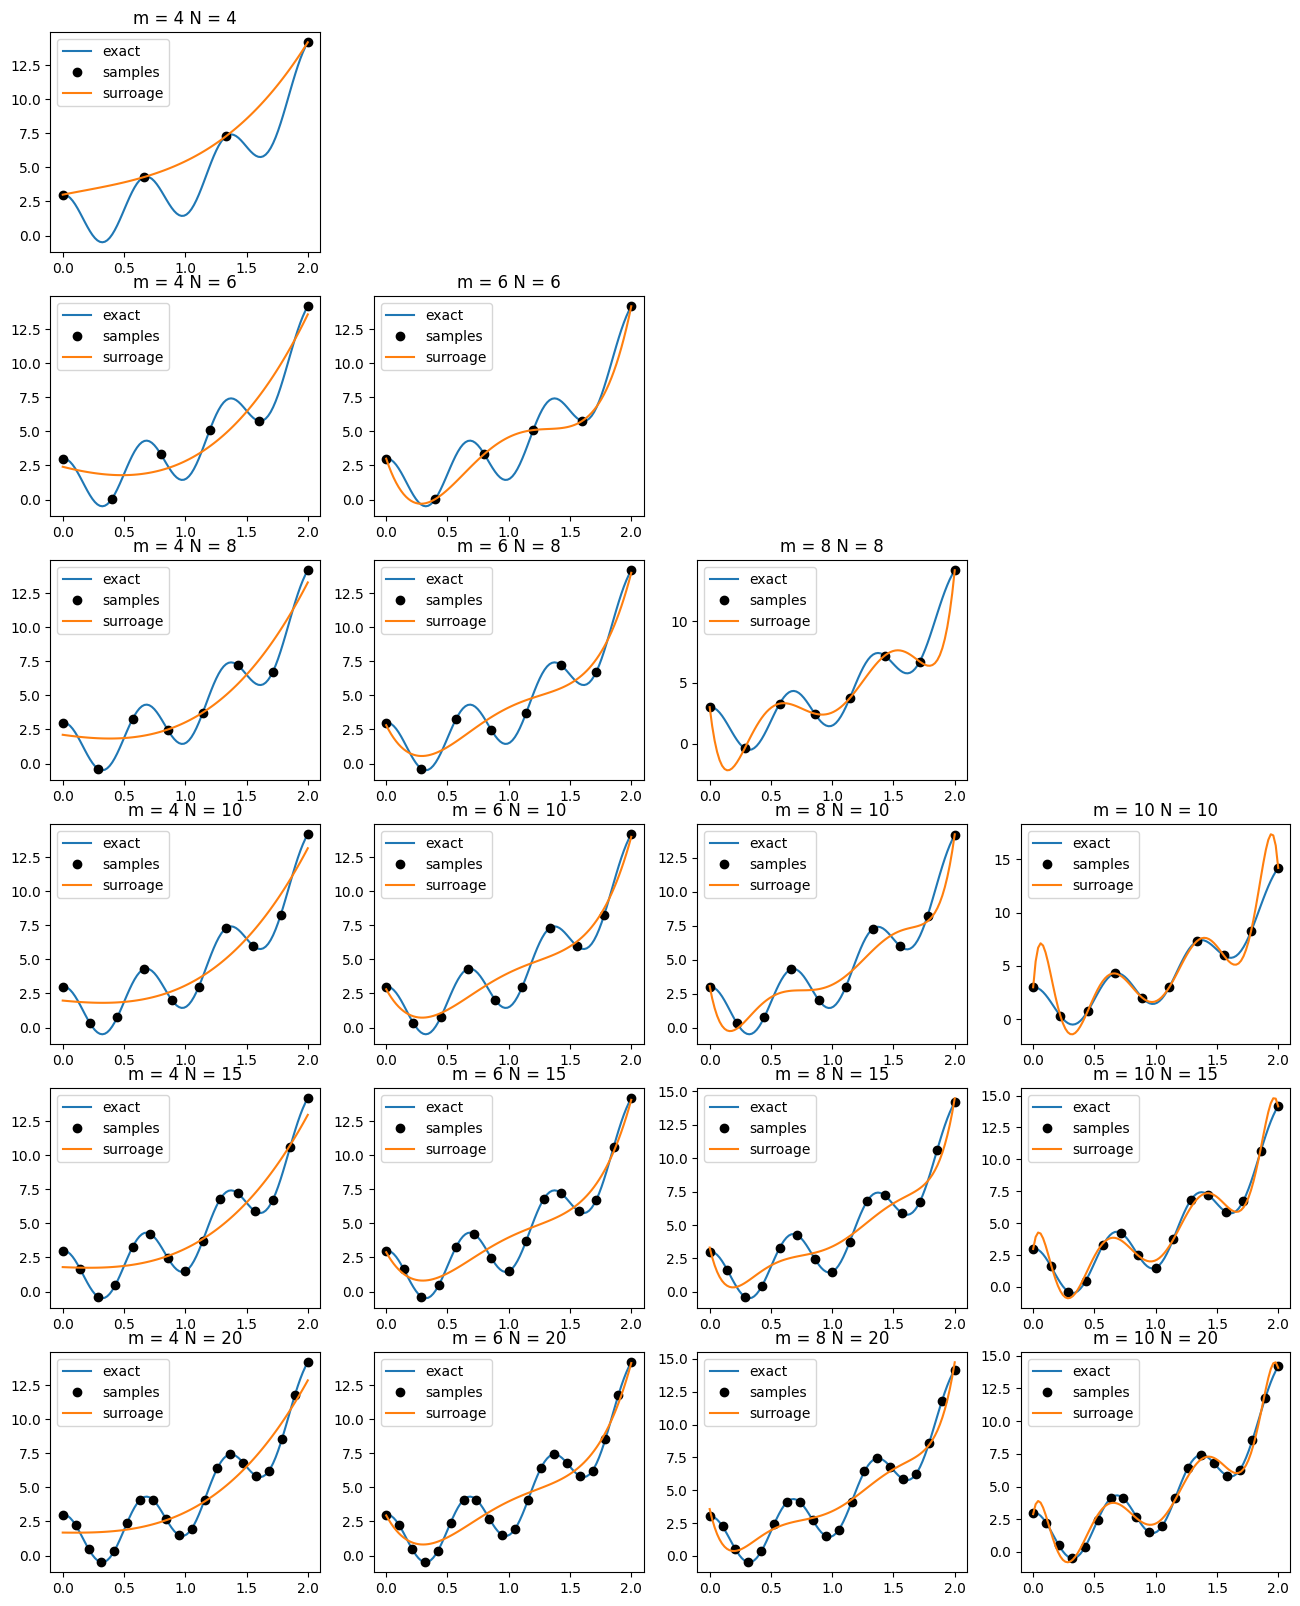

In [4]:
import numpy as np
import matplotlib.pylab as plt

# The function of interest
def f1(x):
    return np.exp(5*x/4) + 2*np.cos(3*np.pi*x)

# Evaluate the polynomial using Horner's method
def eval_poly(w, x):
    fhat = 0.0
    for wi in w[::-1]:
        fhat = wi + x*fhat
    return fhat

# From the given sample set, construct the model of the function
def construct_poly_surrogate(m, xi, func):
    N = len(xi)
    f = np.zeros(N)

    # Form the matrix phi
    Phi = np.zeros((N, m))
    Phi[:,0] = 1.0

    # Evaluate the function
    for i, x in enumerate(xi):
        f[i] = func(x)

        for j in range(1,m):
            Phi[i,j] = x**j

    return np.linalg.solve(np.dot(Phi.T, Phi), np.dot(Phi.T, f))

xlow = 0
xhigh = 2

# Set the samples
x = np.linspace(xlow, xhigh, 100)

mlist = [4, 6, 8, 10]
Nlist = [4, 6, 8, 10, 15, 20]

fig, ax = plt.subplots(len(Nlist), len(mlist), figsize=(16, 20))

for im, m in enumerate(mlist):
    for iN, N in enumerate(Nlist):
        if N < m:
            ax[iN, im].axis('off')
            continue

        # Evenly space the sample points
        xi = np.linspace(xlow, xhigh, N)
        
        # Distribute the sample points in a cosine spacing
        # y = 0.5*(1.0 - np.cos(np.linspace(0, np.pi, N)))
        # xi = xlow + (xhigh - xlow)*y

        w = construct_poly_surrogate(m, xi, f1)

        fhat = np.zeros(x.shape)
        for i, xval in enumerate(x):
            fhat[i] = eval_poly(w, xval)

        ax[iN, im].set_title('m = %d N = %d'%(m, N))
        ax[iN, im].plot(x, f1(x), label='exact')
        ax[iN, im].plot(xi, f1(xi), 'ko', label='samples')
        ax[iN, im].plot(x, fhat, label='surroage')
        ax[iN, im].legend()
        
plt.show()

### Measuring the quality of the surrogate model

*Overfitting* occurs when the output model data is fit too closely by the surrogate model. When a model suffers from overfitting, additional predictions from the surrogate will have large error compared with the true model.

For the above case when $m = 10$ and $N = 20$, the model overshoots at the edges of the domain. This results in the Runge phenomenon where the surrogate model will oscillate rapidly near the edges of the interval.

We will need to develop a measure for the quality of the fit. Given a set of sample points, the sum square error is

\begin{equation*}
SSE = e^{T}e
\end{equation*}

where the components of the error $e$ are given by

\begin{equation*}
e_{i} = f(x_{i}) - \hat{f}(x_{i}) 
\end{equation*}

The sum square error at the sample points will be low, since we minimize this to obtain the surrogate model itself.
However, if we validate against a new set of points (the *validation set*), this will give us a good indication of the error.

The problem with the SSE metric is that it depends on the magnitude of the error. To non-dimensionalize the error, we can use the total sum squares computed as

\begin{equation*}
SST = s^{T}s
\end{equation*}

where $s$ is defined as

\begin{equation*}
s_{i} = f(x_{i}) - \frac{1}{N} \sum_{i=1}^{N} f(x_{i})
\end{equation*}

Instead, we can look at a unitless metric for the error, called the *coefficient of determination*, or $R^{2}$ value where

\begin{equation*}
R^{2} = 1 - \frac{SSE}{SST}
\end{equation*}

* $R^2$ values close to $1$ indicate a good fit to the data
* $R^2$ values further away from $1$ indicate a bad fit to data

$R^2$ values against the *sample set* should be close to 1. But it is much more meaningful to examine the $R^2$ on the *validation set*, since these represent points that model must predict without knowning in advance.

## Regularization

Regularization is a powerful tool for obtaining smooth models. Often model dependence should reflect underlying sparsity between the input data and output. Regularization can be used to find a surrogate when there are fewer sample points than basis functions $N < m$.

The $\ell_{2}$ regularization approaches add a term to the original problem of minimizing the sum square of errors problem such that

\begin{equation*}
\min_{w} e^{T}e + \theta w^{T}w
\end{equation*}

where $\theta > 0$ is a regularization parameter.
Note that here we're minimizing the sum square of the error at the sample points with the additional penalty term added for large weight values.

To obtain the solution, apply the first-order necessary conditions

\begin{equation*}
2 e^{T} \frac{\partial e}{\partial w} + 2\theta w^{T} = 0
\end{equation*}

This gives the relationship

\begin{equation*}
- \Phi^{T} e + \theta w = \Phi^{T} (\Phi w - f) + \theta w = (\Phi^{T}\Phi + \theta 1)w - \Phi^{T} f = 0 
\end{equation*}

The solution is
\begin{equation*}
(\Phi^{T}\Phi + \theta 1)w = \Phi^{T} f 
\end{equation*}

$\Phi^{T}\Phi$ is positive semi-definite, but $\theta 1$ is always positive definite. 
Therefore $(\Phi^{T}\Phi + \theta 1)$ is positive definite whenever $\theta > 0$.

## Polynomials in multiple dimensions

In many cases, we want to build a surrogate model in multiple dimensions.
Polynomials can be attractive since they are smooth an easy to evaluate.
However, it can be impractical to use high-degree polynomials in surrogate models.

Consider the basis functions in 3d space for cubics.
This corresponds to the following sets of basis functions:

\begin{equation*}
\begin{aligned}
& 1, \\
& x_{1}, x_{2}, x_{3},\\
& x_{1}^2, x_{2}^2, x_{3}^2, x_{1}x_{2}, x_{1}x_{3}, x_{2}x_{3} \\
& x_{1}^3, x_{2}^3, x_{3}^3,
x_{1}^2 x_{2}, x_{1}^2 x_{3},
x_{2}^2 x_{1}, x_{2}^2 x_{3},
x_{3}^2 x_{1}, x_{3}^2 x_{2},
x_{1}x_{2}x_{3}
\end{aligned}
\end{equation*}

These are grouped into the homogenous monomials. For a given degree $p$, there are

\begin{equation*}
\frac{(p + n - 1)!}{p!(n-1)!}
\end{equation*}

monomial terms. For $n = 3$, this gives 1 term for $p = 0$, 3 terms for $p = 1$, 6 terms for $p = 2$ and 10 terms for $p = 3$.
As $n$ and $p$ grow, the total number of polynomial terms grows rapidly.

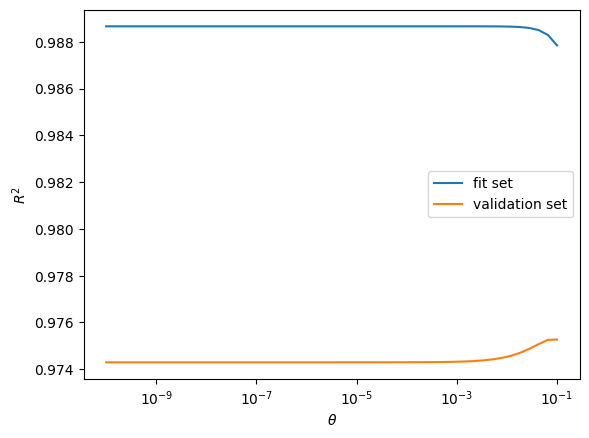

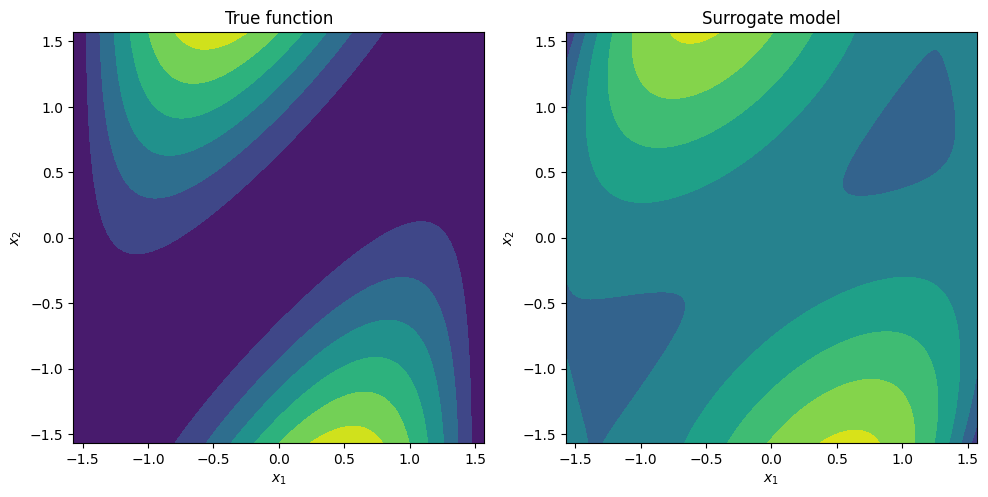

In [5]:
import numpy as np
import matplotlib.pylab as plt

# Set the initial random seed = 0
np.random.seed(0)

# The 2d function of interest
def f1(x):
    return np.cos(x[0])*np.sin(0.5*(x[1] - x[0]))**2

def eval_basis(x):
    return np.array(
    [1.0,
     x[0], x[1],
     x[0]**2, x[1]**2, x[0]*x[1],
     x[0]**3, x[1]**3, x[0]**2*x[1], x[0]*x[1]**2,
     x[0]**4, x[1]**4, x[0]**3*x[1], x[0]*x[1]**3, x[0]**2*x[1]**2])

def eval_surrogate(w, x):
    phi = eval_basis(x)
    return np.dot(phi, w)

def construct_surrogate(theta, xi, func):
    # Form the matrix Phi and the vector f
    Phi, f = [], []
    for x in xi:
        Phi.append(eval_basis(x))
        f.append(func(x))
    Phi = np.array(Phi)
    f = np.array(f)
    
    # Solve for the coefficients
    A = np.dot(Phi.T, Phi) + theta*np.eye(Phi.shape[1])
    return np.linalg.solve(A, np.dot(Phi.T, f))

def validate(xi, func, surrogate):
    N = len(xi)
    fvals = np.zeros(N)
    fhat = np.zeros(N)
    for i, x in enumerate(xi):
        fvals[i] = func(x)
        fhat[i] = surrogate(x)
    
    fmean = np.sum(fvals)/N
    R2 = 1.0 - np.sum((fvals - fhat)**2)/np.sum((fvals - fmean)**2)
    
    return R2

N = 50
Nvalidate = 100

low = -0.5*np.pi
high = 0.5*np.pi
xfit = np.random.uniform(low=low, high=high, size=(N, 2))
xvalidate = np.random.uniform(low=low, high=high, size=(Nvalidate, 2))

theta_range = 10**np.linspace(-10, -1)
r2_fit = np.zeros(len(theta_range))
r2_validate = np.zeros(len(theta_range))

for i, theta in enumerate(theta_range):
    w = construct_surrogate(theta, xfit, f1)
    surrogate = lambda x : eval_surrogate(w, x)

    r2_fit[i] = validate(xfit, f1, surrogate)
    r2_validate[i] = validate(xvalidate, f1, surrogate)    

plt.figure()
plt.semilogx(theta_range, r2_fit, label='fit set')
plt.semilogx(theta_range, r2_validate, label='validation set')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$R^{2}$')
plt.legend()

# Reconstruct the surrogate
w = construct_surrogate(0.0, xfit, f1)
surrogate = lambda x : eval_surrogate(w, x)

s = 100
x = np.linspace(low, high, s)
y = np.linspace(low, high, s)
X, Y = np.meshgrid(x, y)
F = np.zeros(X.shape)
Fhat = np.zeros(X.shape)

for j in range(s):
    for i in range(s):
        xval = np.array([X[i,j], Y[i,j]])
        F[i,j] = f1(xval)
        Fhat[i,j] = surrogate(xval)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].contourf(X, Y, F)
ax[0].set_aspect('equal', 'box')
ax[0].set_xlabel(r'$x_1$')
ax[0].set_ylabel(r'$x_2$')  
ax[0].set_title('True function')

ax[1].contourf(X, Y, Fhat)
ax[1].set_aspect('equal', 'box')
ax[1].set_xlabel(r'$x_1$')
ax[1].set_ylabel(r'$x_2$')    
ax[1].set_title('Surrogate model')
fig.tight_layout()
        
plt.show()


## Radial basis functions

Polynomials are difficult to extend to higher dimensions.
Radial basis functions (RBFs) are a form of surrogate model that is more easily extensible to higher dimensional design spaces.
It's also easier to locally reduce errors using these types of models.

The radial basis function is written in terms of a radial distance

\begin{equation*}
r_{i}(x) = ||x - x_{i}||_{2} 
\end{equation*}

where $r_{i}(x)$ is the Euclidean distance from point the point $x_{i}$ to $x$. The radial function $r_{i}(x) : \mathbb{R}^{n} \rightarrow \mathbb{R}$ takes the design variables as an argument and returns the scalar radial distance.

Next, we specify how the basis function behaves as a function of the radial distance via a scalar function $\phi(r) : \mathbb{R} \rightarrow \mathbb{R}$. Some common choices for these radial basis functions are

* Multiquadric
\begin{equation*}
\phi(r) = \sqrt{r^2 + r_{0}^2}
\end{equation*}

* Inverse multiquadric
\begin{equation*}
\phi(r) = \frac{1}{\sqrt{r^2 + r_{0}^2}}
\end{equation*}

* Thin plate spline
\begin{equation*}
\phi(r) = r^2 \ln\left(\frac{r}{r_{0}}\right)
\end{equation*} 

* Gaussian 
\begin{equation*}
\phi(r) = e^{-r^2/r_{0}^2}
\end{equation*}

* Cubic
\begin{equation*}
\phi(r) = 1 + \frac{r^3}{r_{0}^3}
\end{equation*}

Finally, the basis functions for the surrogate model are evaluated via composition such that

\begin{equation*}
\phi_{i}(x) = \phi(r_{i}(x))
\end{equation*}

where $\phi(r)$ is a basis function that is the same for all points.
With this definition, the model form can be written as

\begin{equation*}
\hat{f}(x) = \sum_{i=1}^{N} w_{i} \phi(r_{i}(x))
\end{equation*}

Model construction and validation takes place in exactly the same way as the other surrogate modeling techniques.
Often RBF models are interpolating, but this is not required.

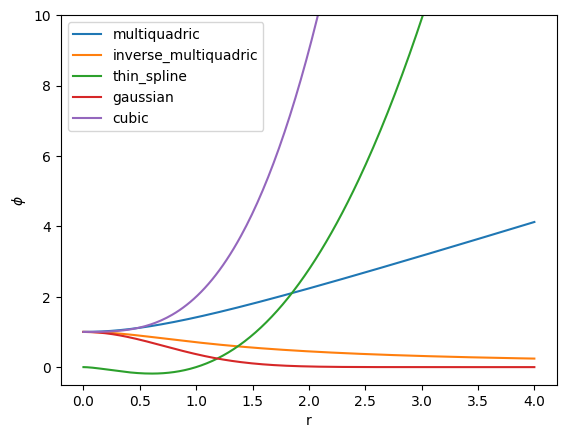

In [6]:
import numpy as np
import matplotlib.pylab as plt

def multiquadric(r, r0=1.0):
    return np.sqrt(r**2 + r0**2)

def inverse_multiquadric(r, r0=1.0):
    return 1.0 / np.sqrt(r**2 + r0**2)

def thin_spline(r, r0=1.0, eps=1e-3):
    return r**2 * np.log(r / r0 + eps)

def gaussian(r, r0=1.0):
    return np.exp(-r**2 / r0**2)

def cubic(r, r0=1.0):
    return 1.0 + r**3 / r0**3

basis = [multiquadric, inverse_multiquadric, thin_spline, gaussian, cubic]

n = 250
r = np.linspace(0, 4, n)

fig, ax = plt.subplots(1, 1)

for func in basis:
    phi = func(r)
    ax.plot(r, phi, label=func.__name__)

plt.legend()
ax.set(xlabel="r")
ax.set(ylabel=r"$\phi$")
ax.set_ylim(-0.5, 10)
plt.show()

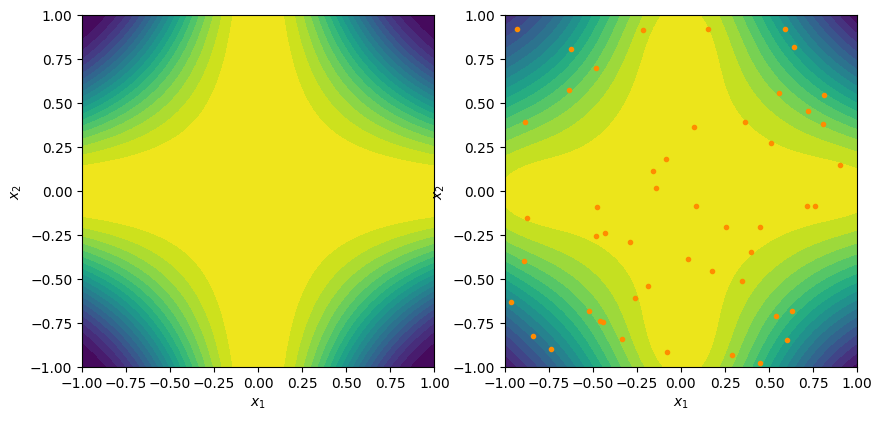

In [7]:
import numpy as np
import matplotlib.pylab as plt

def contour_plot(func, ax=None, low=-1, high=1, levels=20):
    s = 100
    x = np.linspace(low, high, s)
    y = np.linspace(low, high, s)
    X, Y = np.meshgrid(x, y)

    F = np.zeros(X.shape)

    for j in range(s):
        for i in range(s):
            xval = np.array([X[i,j], Y[i,j]])
            F[i,j] = func(xval)

    if ax is None:
        fig, ax = plt.subplots(1, 1)
        
    ax.contourf(X, Y, F, levels=levels)
    ax.set_aspect('equal', 'box')
    ax.set_xlabel(r'$x_1$')
    ax.set_ylabel(r'$x_2$')
    return

def f1(x):
    """The true function"""
    return np.cos(np.pi*x[0]*x[1])

def eval_rbf(x, w, xi, rbf):
    """Evaluate the RBF"""
    N = len(xi)
    fhat = 0.0
    for i in range(N):
        r = np.sqrt(np.dot(x - xi[i], x - xi[i]))
        fhat += w[i]*rbf(r)
    return fhat

def gaussian(r):
    """Return the radial basis function"""
    return np.exp(-0.25*r**2)

def multiquad(r):
    """Return the multiquadratic basis function"""
    return np.sqrt(1.0 + r**2)

# From the given sample set, construct the model of the function
def construct_rbf(xi, rbf, func):
    N = len(xi)
    f = np.zeros(N)

    # Form the matrix Phi
    Phi = np.zeros((N, N))

    # Evaluate the function
    for i in range(N):
        f[i] = func(xi[i])

        for j in range(N):
            r = np.sqrt(np.dot(xi[i] - xi[j], xi[i] - xi[j]))
            Phi[i,j] = rbf(r)

    return np.linalg.solve(Phi, f)

# Select a random set of sample points
xi = np.random.uniform(low=-1, high=1, size=(50, 2))

# Select the basis function
rbf = multiquad

# Construct the surrogate model
w = construct_rbf(xi, rbf, f1)
surrogate = lambda x : eval_rbf(x, w, xi, rbf)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
contour_plot(f1, ax=ax[0], levels=20)
contour_plot(surrogate, ax=ax[1], levels=20)
ax[1].plot(xi[:,0], xi[:,1], linestyle='None', marker='o', 
           color='darkorange', markersize=3)

plt.show()

## Design of experiments

In this section, we'll go into more detail about sampling techniques.

### Full factorial

Full factorial sampling methods take samples along each design variable coordinate. If there are $n$ design variables and $r$ samples along each design direction, there are a total of $N = r^{n}$ samples.

#### Evenly spaced samples

The most straightforward way to sample in a full factorial design is to evenly space the samples along each direction. In this case the sample coordinate is given $x_{i} \in [a, b]$

\begin{equation*}
x_{i} = a + (b - a)\dfrac{(i - 1)}{(r - 1)} \qquad i = 1, \ldots, r
\end{equation*}

#### Chebyshev nodes or cosine spacing

To reduce the Runge phenomena, it can be beneficial to apply a cosine spacing of the sample points. In this case the sample are given by

\begin{equation*}
x_{i} = a + \dfrac{(b - a)}{2}\left(1 - \cos\left(\pi \dfrac{(i - 1)}{(r - 1)} \right) \right) \qquad i = 1, \ldots, r
\end{equation*}

This spacing is especially beneficial in the context of higher-order polynomial surrogate models.

### Random sampling

Pseudo-random sampling methods generate a set of points by randomly assigning the coordinates of each point. Unfortunately, this can lead to uneven distribution of points over the design domain. Closely clustered points lead to over sampling of some areas of the design space compared to others. As a result, a random or pseudo-random sampling of the design space is not recommended in practice.

### Latin Hypercube Sampling (LHS)

LHS is a method for generating a quasi-random sampling of the design space.

From https://en.wikipedia.org/wiki/Latin_hypercube_sampling

> In the context of statistical sampling, a square grid containing sample positions is a Latin square if and only if there is only one sample in each row and each column. A Latin hypercube is the generalisation of this concept to an arbitrary number of dimensions, whereby each sample is the only one in each axis-aligned hyperplane containing it.

To generate an LHS sample set with $N$ sample points in $n$ dimensions over the interval $[a, b]$, you can perform the following steps:

1. Create a temporary set of sample points $\hat{x}_{i}$ for $i = 1,\ldots,N$.
2. For each sample point compute a new random number $r \in [0, 1]$ and compute

\begin{equation*}
\left[\hat{x}_{i}\right]_{j} = a + (b - a)\left( \frac{i}{N} + \frac{r}{N} \right)
\end{equation*}

3. For each coordinate direction, randomly permute the $\hat{x}_{i}$ from the temporary samples into the final samples $x_{i}$.

### Low-discrepancy sequences

Low-discrepancy sequences have the property that that two samples will lie close to one another is lower than a randomly generated sample. These low discrepancy sample points perform better in the context of sampling methods than full random samples.

To generate low-discrepancy sequences, we'll use following representation of an integer $i$ in a basis $b$

\begin{equation*}
i = a_{0} + a_{1} b + a_{2} b^2 + \ldots + a_{r} b^{r} 
\end{equation*}

Each of the coefficients $a_{i}$, $i = 0, r$ are between $a_{i} \in [0, b-1]$.

We can then generate a sequence in one-dimension by specifying a basis $b$ and computing the $i$-th element of the sequence

\begin{equation*}
g(i, b) = \sum_{i=0}^{r} \dfrac{a_{i}}{b^{i+1}}
\end{equation*}

This generating function is called the radical inverse function and generates the $i$-th element of the van der Corput sequence.

### Halton sequences

A Halton sequence is generated by selecting pair-wise prime numbers along each dimension $b_{j}$ for $j = 1, \ldots n$, and the computing the vector $x_{i}$ as

\begin{equation*}
x_{i} = \begin{bmatrix}
a + (b - a) g(i, b_{1}) \\ 
a + (b - a) g(i, b_{2}) \\ 
\vdots \\
a + (b - a) g(i, b_{n}) \\ 
\end{bmatrix}
\end{equation*}

for $i = 1, \ldots, N$.

Some care is required in higher dimensions, since the Halton sequence becomes more clustered as the generating prime numbers, $b_{j}$, become larger. In this case, the sequence $i$ can be based on a random permutation of the integers from $i = 1, \ldots, N$.

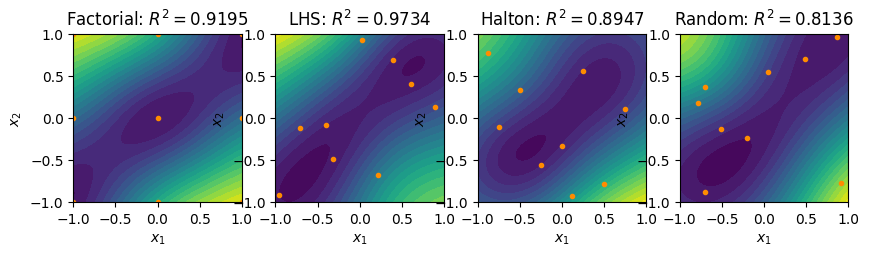

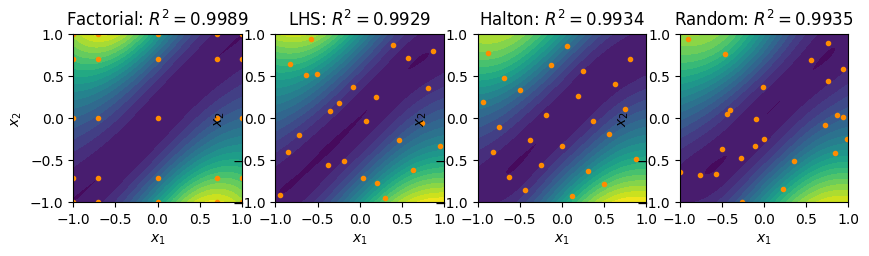

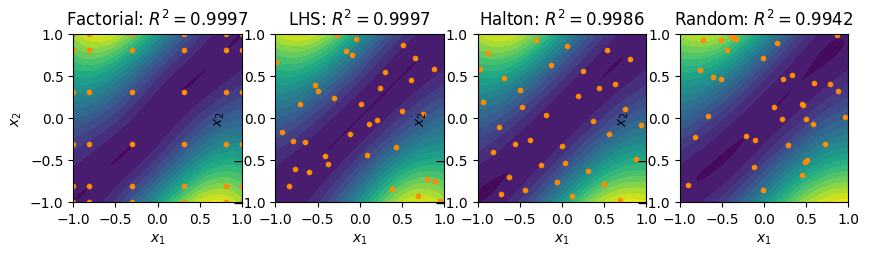

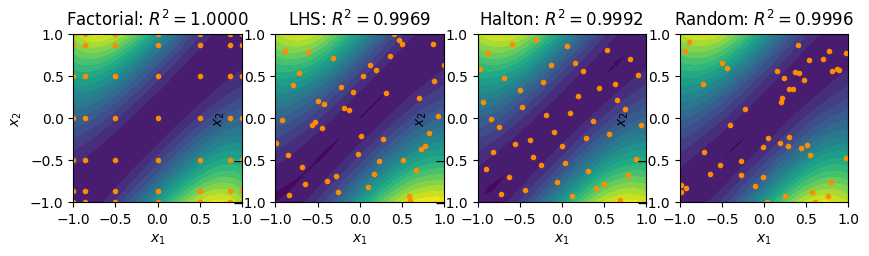

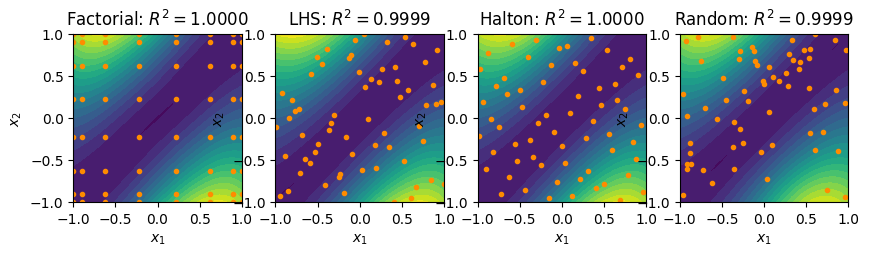

In [8]:
import numpy as np
import matplotlib.pylab as plt

def multiquad(r):
    """Return the multiquadratic basis function"""
    return np.sqrt(1.0 + r**2)

# The 2d function of interest
def f1(x):
    return np.cos(x[0])*np.sin(0.5*(x[1] - x[0]))**2

def factorial(n, Ndir, low=-1.0, high=1.0):
    """
    Generate a full-factorial design using different spacing
    
    Args:
        n (int): The dimension of the design space
        Ndir (int): The number of samples along each direction
    """
    
    # Generate the cosine distribution from [0, 1]
    u = 0.5 - 0.5 * np.cos(np.linspace(0, np.pi, Ndir))
    
    # Generate the points along one direction
    x = low + (high - low)*u
    
    # Generate all the points
    N = Ndir**n
    pts = np.zeros((N, n))
    
    # Set the index
    index = np.zeros(n, dtype=int)
    
    for j in range(N):
        for i in range(n):
            pts[j, i] = x[index[i]]
            
        # Increment the index
        index[0] += 1
        for i in range(n-1):
            if index[i] >= Ndir:
                index[i+1] += 1
                index[i] = 0
    
    return pts

def lhs(n, N, low=-1.0, high=1.0):
    """
    Create a Latin hypercube sample set
    
    Args:
        n (int): The dimension of the design space
        N (int): The number of samples
    """
    
    # Generate the intervals
    u = np.linspace(low, high, N+1)
    u0 = u[:-1]
    du = u[1:] - u[:-1]
    
    # Create random points for each interval
    pts = np.zeros((N, n))
    for j in range(n):
        pts[:, j] = u0 + du*np.random.uniform(size=N)
        
    # Randomly permute the points
    for j in range(n):
        perm = np.random.permutation(N)
        pts[:, j] = pts[perm, j]
        
    return pts

def get_primes(n):
    """
    Get the first n prime values
    """
    
    num = 2
    primes = []
    while len(primes) < n:
        for i in range(2, num):
            if num % i == 0:
                break
        else:
            primes.append(num)
        num += 1
    
    return primes

def vanderCorput(i, b):
    """
    Compute the radical inverse function on the interval [0, 1]
    
    Given the input integer i > 0 and the base b input 
    return the radical inverse value

    Args:
        i (int): Integer greater than 0
        b (int): Base value
        
    Returns:
        The radical inverse value
    """
    
    bpow = b
    val = 0.0
    while i > 0:
        a = i % b
        val = val + a/bpow
        bpow *= b
        i = (i - a)//b
    
    return val

def halton(n, N, low=-1.0, high=1.0):
    """
    Generate a Halton series
    """
    
    # Allocate the points
    pts = np.zeros((N, n))

    # Get the basis for the values
    b = get_primes(n)
    
    for i in range(N):
        for j in range(n):
            pts[i, j] = low + (high - low) * vanderCorput(i + 1, b[j])
            
    return pts

# The spatial dimension
n = 2

xvalidate = np.random.uniform(low=-1, high=1, size=(100, 2))

for N in [9, 25, 36, 49, 64]:
    fact_pts = factorial(n, int(np.sqrt(N)))
    lhs_pts = lhs(n, N)
    halton_pts = halton(n, N)
    rand_pts = np.random.uniform(low=-1, high=1, size=(N, 2))
    
    rbf = multiquad

    # Build a surrogate from the full factorial design
    fact_w = construct_rbf(fact_pts, rbf, f1)
    fact_surrogate = lambda x : eval_rbf(x, fact_w, fact_pts, rbf)
    
    # Build a surrogate from the LHS points
    lhs_w = construct_rbf(lhs_pts, rbf, f1)
    lhs_surrogate = lambda x : eval_rbf(x, lhs_w, lhs_pts, rbf)

    # Build a surrogate from the Halton points
    halton_w = construct_rbf(halton_pts, rbf, f1)
    halton_surrogate = lambda x : eval_rbf(x, halton_w, halton_pts, rbf)

    # Build a surrogate from the random points
    rand_w = construct_rbf(rand_pts, rbf, f1)
    rand_surrogate = lambda x : eval_rbf(x, rand_w, rand_pts, rbf)

    R2_fact = validate(xvalidate, fact_surrogate, f1)
    R2_lhs = validate(xvalidate, lhs_surrogate, f1)
    R2_halton = validate(xvalidate, halton_surrogate, f1)
    R2_rand = validate(xvalidate, rand_surrogate, f1)
    
    fig, ax = plt.subplots(1, 4, figsize=(10, 5))
    contour_plot(fact_surrogate, ax=ax[0])
    ax[0].plot(fact_pts[:,0], fact_pts[:,1], linestyle='None', marker='o', 
               color='darkorange', markersize=3)
    ax[0].set_title(r'Factorial: $R^2 = %.4f$'%(R2_fact))
    
    contour_plot(lhs_surrogate, ax=ax[1])
    ax[1].plot(lhs_pts[:,0], lhs_pts[:,1], linestyle='None', marker='o', 
               color='darkorange', markersize=3)
    ax[1].set_title(r'LHS: $R^2 = %.4f$'%(R2_lhs))

    contour_plot(halton_surrogate, ax=ax[2])
    ax[2].plot(halton_pts[:,0], halton_pts[:,1], linestyle='None', marker='o', 
               color='darkorange', markersize=3)
    ax[2].set_title(r'Halton: $R^2 = %.4f$'%(R2_halton))

    contour_plot(rand_surrogate, ax=ax[3])
    ax[3].plot(rand_pts[:,0], rand_pts[:,1], linestyle='None', marker='o', 
               color='darkorange', markersize=3)
    ax[3].set_title(r'Random: $R^2 = %.4f$'%(R2_rand))

plt.show()
    

## Neural Networks

The example and notes here are based on the material presented here:

http://neuralnetworksanddeeplearning.com/

Up to this point, we've looked at linear regression models where the model form $\hat{f}(x)$ is a linear function of the weights.
In addition, we've looked at surrogates that generate a single output.
Deep neural networks introduce a nonlinear relationship between the weights or model parameters and the output and provide for the potential for multiple outputs from a given input.

A key idea aspect of neural networks is that they utilize intermediate or hiden layers in the network to map inputs to outputs. Networks that combine multiple layers together are called deep neural networks.

As a starting point, we'll consider a single layer of a neural network.
We can then combine multiple layers together to compute an output.
At the first layer, we'll consider the inputs to the layer $y_{j}^{(1)}$ for $j = 1, \ldots, n$.
The inputs are used to compute an intermediate variable $z_{i}^{(1)}$ for $i = 1, \ldots, m$ using a linear relationship

\begin{equation*}
z_{i}^{(1)} = \sum_{j=1}^{n} W_{ij}^{(1)} y_{j}^{(1)} + b_{i}^{(1)} \qquad i = 1, \ldots, m
\end{equation*}

Both the weights $W^{(1)}_{ij}$ and the bias $b^{(1)}_{i}$ can be treated as model parameters to be adjusted to fit the data.
This relationshp can be expressed in matrix form as

\begin{equation*}
z^{(1)} = W^{(1)} y^{(1)} + b^{(1)}
\end{equation*}

Next, we take the intermediate variable $z^{(1)}_{i}$ and we pass it through an activation function.
A common activation function was the sigmoid function

\begin{equation*}
a(z) = \dfrac{1}{1 + e^{-z}}
\end{equation*}

The sigmoid function is a rough approximation of the step function.
However, this introduces a strong nonlinear dependence on the output. 

Most modern neural networks utilize a simpler activation function, called the rectified linear function or ReLU that takes the form

\begin{equation*}
a(z) = \max(0, z)
\end{equation*}

The outputs to the next layer are then computed as

\begin{equation*}
y_{j}^{(2)} = a(W^{(1)} y^{(1)} + b^{(1)})
\end{equation*}

Multiple layers can now be composed to form a more complicated relationship between inputs and outputs.
For instance, a simple two layer model would consist of the following relationships

\begin{equation*}
\begin{aligned}
y^{(1)} &= x \\
y^{(2)} &= a(W^{(1)} y^{(1)} + b^{(1)}) \\
y^{(3)} &= a(W^{(2)} y^{(2)} + b^{(2)}) \\
\hat{f}(x) &= y^{(3)} \\
\end{aligned}
\end{equation*}

Here, the outputs $\hat{f}(x)$ depend on the weighting matrices $W^{(1)}$ and $W^{(2)}$ as well as the bias vectors $b^{(1)}$ and $b^{(2)}$. Due to the composition and the nonlinear activation function, the output is a nonlinear function of both $x$ *and* the model parameters.

### Least squares objective and backpropagation

The objective function in this case is the sum of the squares of the errors at the sample points.
This objective is computed as

\begin{equation*}
\sum_{i=1}^{N} || f(x_{i}) - \hat{f}(x) ||_{2}^{2}
\end{equation*}

Note that this objective function is compatible with multiple outputs, i.e. when $\hat{f}(x)$ is vector valued.
In the neural network, the model parameters are the weighting matrix, $W^{(k)}$, and the bias $b^{(k)}$.
As a result, the minimization problem can be stated as

\begin{equation*}
\min_{W^{(k)}, b^{(k)}} \sum_{i=1}^{N} || f(x_{i}) - \hat{f}(x) ||_{2}^{2}
\end{equation*}

Neural networks are typically trained with methods similar to the steepest descent method.
To optimize for the weights, we therefore need the gradient of the sum square of errors with respect to the model parameters $W^{(k)}$, $b^{(k)}$.

This gradient is typically obtained with automatic differentation methods which, in the context of machine learning, is often called backpropagation. 
In the example code below, we can apply AD methods to obtain the derivative of the output with respect to the inputs for training the model.

The task of the automatic differentation is to compute the updates to $\bar{W}^{(k)}$, $\bar{y}^{(k)}$ and $\bar{b}^{(k)}$ given the input $\bar{y}^{(k+1)}$.
Here we have the relationship for the forward derivative

\begin{equation*}
\dot{y}^{(k+1)} = \dfrac{\partial a}{\partial z} \left(\dot{W}^{(k)} y^{(k)} + W^{(k)} \dot{y}^{(k)} + \dot{b}^{(k)}\right)
\end{equation*}

The reverse mode AD relationships can be found as follows

\begin{equation*}
\left[\bar{y}^{(k+1)}\right]^{T}\dot{y}^{(k+1)} = \left[\bar{y}^{(k+1)}\right]^{T} \left[ \dfrac{\partial a}{\partial z}^{T} \left((\dot{W}^{(k)} y^{(k)} + W^{(k)} \dot{y}^{(k)} + \dot{b}^{(k)}\right) \right]
\end{equation*}

Before collecting terms, it is helpful to introduce an intermediate variable $\bar{z}$ defined as

\begin{equation*}
\bar{z} = \dfrac{\partial a}{\partial z}^{T} \bar{y}^{(k+1)}
\end{equation*}

Note that the matrix ${\partial a}/{\partial z}$ is diagonal and stored as a vector in the code.
The updates to $\bar{W}^{(k)}$, $\bar{y}^{(k)}$ and $\bar{b}^{(k)}$ are given by

\begin{equation*}
\begin{aligned}
\bar{b}^{(k)} &= \bar{z} \\
\bar{W}^{(k)} &= \bar{z} {y^{(k)}}^{T} \\
\bar{y}^{(k)} &= {W^{(k)}}^{T} \bar{z} \\
\end{aligned}
\end{equation*}

Complex step              Auto-diff                 Relative error           
    4.889357727156226e-15     4.889357727156226e-15     0.000000000000000e+00
    0     4.800927481820299e-01
  100     1.892263683312594e-01
  200     2.253619398313697e-02
  300     1.636311238719816e-02
  400     1.136839766673297e-01
  500     7.212705940344225e-02
  600     1.959739046320806e-02
  700     2.143589443103296e-02
  800     6.147362508461649e-03
  900     4.748924479508359e-03


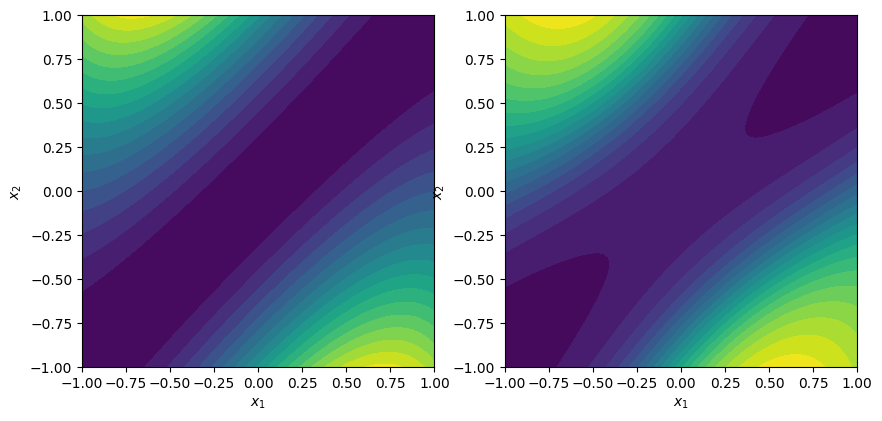

In [9]:
"""
Simple neural network example
"""

def f1(x):
    return np.cos(x[0])*np.sin(0.5*(x[1] - x[0]))**2

def sigmoid(z):
    """Return the value of the sigmoid function"""
    return 1.0/(1.0 + np.exp(-z))

def sigmoid_deriv(z):
    """Return the derivative of the sigmoid function"""
    t = np.exp(-z)
    return t/(1.0 + t)**2

def relu(z):
    return np.maximum(0.0, z)

def relu_deriv(z):
    dfdx = np.ones(z.shape)
    dfdx[z <= 0.0] = 0.0
    return dfdx

def leaky_relu(z, alpha=0.001):
    return np.where(z > 0.0, z, alpha * z)

def leaky_relu_deriv(z, alpha=0.001):
    return np.where(z > 0.0, 1.0, alpha)

class NeuralNetLayer:
    def __init__(self, n_inputs, n_outputs, act, act_deriv, dtype=float):
        """
        Create a layer for the neural network
        """
        self.n_inputs = n_inputs
        self.n_outputs = n_outputs
        self.act = act
        self.act_deriv = act_deriv
        
        # Forward input/output data
        self.y = np.zeros(self.n_inputs, dtype=dtype)
        self.z = np.zeros(self.n_outputs, dtype=dtype)
        self.output = np.zeros(self.n_outputs, dtype=dtype)
        
        # Allocate the forward data
        self.W = np.random.uniform(size=(self.n_outputs, self.n_inputs)).astype(dtype) # , dtype=dtype)
        self.b = np.zeros(self.n_outputs, dtype=dtype)
        
        # Allocate the reverse data
        self.Wb = np.zeros((self.n_outputs, self.n_inputs), dtype=dtype)
        self.bb = np.zeros(self.n_outputs, dtype=dtype)
        
        return
    
    def forward(self, y):
        """Compute a(W*y + b)"""
        self.y[:] = y[:] # Save the input data
        self.z[:] = np.dot(self.W, self.y) + self.b
        self.output[:] = self.act(self.z)
        return 
    
    def zero(self):
        """Zero the derivative"""
        self.Wb[:] = 0.0
        self.bb[:] = 0.0
        return
    
    def reverse(self, outputb):
        """Backwards accumulation"""
        zb = self.act_deriv(self.z) * outputb
        self.Wb += np.outer(zb, self.y)
        self.bb += zb
        return np.dot(self.W.T, zb)
    
class NeuralNet:
    def __init__(self, nlayers, act, act_deriv, dtype=float):
        """
        Construct the neural network
        """
        
        # Create the layers
        self.layers = []
        for i in range(len(nlayers)-1):
            layer = NeuralNetLayer(nlayers[i], nlayers[i+1], act, act_deriv, dtype=dtype)
            self.layers.append(layer)
        
        # Set the number of inputs and outputs to the total neural network
        self.n_inputs = self.layers[0].n_inputs
        self.n_outputs = self.layers[-1].n_outputs
        
        return
    
    def gradient_descent(self, num_epochs, input_data, output_data,
                         mini_batch_size=100, eta=0.01, small=1e-6):
        """
        Perform the training of the neural network using gradient descent
        """
        
        npts = input_data.shape[0]
        max_batch = npts//mini_batch_size
        
        for epoch in range(num_epochs):
            # Get a permutation of the data
            permutation = np.random.permutation(npts)
            
            for batch in range(max_batch):
                # Set the start and end points for the mini-batch size
                perm_start = batch * mini_batch_size
                perm_end = min(npts, (batch + 1) * mini_batch_size)

                # Zero-out the gradient
                for layer in self.layers:
                    layer.zero()

                for k in permutation[perm_start:perm_end]:
                    # Compute the output from the training data
                    self.layers[0].forward(input_data[k, :])

                    # Compute the action of the neural network on
                    # the input training data
                    for i in range(1, len(self.layers)):
                        self.layers[i].forward(self.layers[i-1].output)

                    # Compute the contribution to the error
                    outputb = -(output_data[k, :] - self.layers[-1].output)

                    # Reverse through the layers of the neural network
                    for layer in self.layers[::-1]:
                        yb = layer.reverse(outputb)
                        outputb = yb
                    
                # Compute the magnitude of the gradient
                norm2 = 0.0
                for layer in self.layers:
                    norm2 += np.sum(layer.Wb * layer.Wb) + np.sum(layer.bb * layer.bb)    
                norm2 = np.sqrt(norm2)

                # Compute the step size
                step_size = eta/(norm2 + small)

                # Update the weights and bias values using gradient descent
                for layer in self.layers:
                    layer.W -= step_size * layer.Wb
                    layer.b -= step_size * layer.bb                           
                           
            if epoch % 100 == 0:
                print('{0:5d} {1:25.15e}'.format(epoch, norm2))

        return
    
    def evaluate(self, y):
        """Evaluate the neural network"""
        for layer in self.layers:
            layer.forward(y)
            y = layer.output
        return y
    
    def gradient(self, outputb):
        """Evaluate the gradient given the output seeds"""
        for layer in self.layers:
            layer.zero()
        
        # Reverse through the layers of the neural network
        for layer in self.layers[::-1]:
            yb = layer.reverse(outputb)
            outputb = yb

        return

def check_gradient(act, act_deriv):
    # Create the Neural Network
    nn = NeuralNet([2, 100, 1], act, act_deriv, dtype=complex)

    # Test using the complex-step
    eps = 1e-30
    dW = np.random.uniform(size=nn.layers[0].W.shape)

    # Evaluate the neural net
    x = np.random.uniform(size=2)
    nn.evaluate(x)
    nn.gradient(np.array([1.0]))
    ad = np.sum(nn.layers[0].Wb * dW).real

    # Perturb the weights and evaluate the network again
    nn.layers[0].W += 1j * eps * dW
    cs = nn.evaluate(x)[0].imag/eps

    print('{0:25s} {1:25s} {2:25s}'.format('Complex step', 'Auto-diff', 'Relative error'))
    print('{0:25.15e} {1:25.15e} {2:25.15e}'.format(cs, ad, (cs - ad)/cs))

    return

# Check the gradient of the neural network implementation
check_gradient(sigmoid, sigmoid_deriv)
    
# Create the input data and output data
input_data = halton(2, 400)
output_data = np.zeros((input_data.shape[0], 1))
for k in range(input_data.shape[0]):
    output_data[k, 0] = f1(input_data[k, :])

# Create the Neural Network
nn = NeuralNet([2, 25, 1], sigmoid, sigmoid_deriv)    

# Train the network using gradient descent
num_epochs = 1000
nn.gradient_descent(num_epochs, input_data, output_data, mini_batch_size=25)

# Visualize the output
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
contour_plot(f1, ax=ax[0])
contour_plot(nn.evaluate, ax=ax[1])
plt.show()

## Principal Component Analysis

Principal Component Analysis (PCA) is a technique to reduce the dimensionality of the design problem. The goal is to identify the most important design components in a high-dimensional design space that will capture the most information with a lower dimensional subspace.

With dimensionality reduction there is always going to be a loss of accuracy. But, a smaller design space can still be an attractive goal, especially when the loss of accuracy is minimized.

PCA is a linear technique. There are nonlinear analogues to this type of dimensionality reduction method, however we will not cover them here.

### PCA from an eigenvalue problem

Imagine that we have $p$ samples of the $n$ dimensional design space. We put these samples into a data set $X \in \mathbb{R}^{n \times p}$.

We seek out a linear combination of the columns of $x = X w$ where $w \in \mathbb{R}^{p}$.

Our goal is to find a $w$ such that it covers as much as the design space as possible. To measure the effect on the design space, we can think of maximizing $x^{T} x$. But if $w$ is unconstrained, then we can get larger $x$ values by increasing $w$. So we'll impose a normalization on $w$ such that $w^{T} w = 1$.

The result is the following optimization problem statement 

\begin{equation*}
\begin{aligned}
\max_{w} \qquad & x^{T} x = (X w)^T X w = w^{T} X^{T} X w \\
\text{s.t} \qquad & w^{T} w = 1 
\end{aligned}
\end{equation*}

The Lagrangian of this function is $\mathcal{L}(w, \lambda) = - w^{T} X^{T} X w + \lambda (w^{T} w - 1)$

The KKT conditions for $\nabla_{w} \mathcal{L} = 0$ result in the following equations

\begin{equation*}
X^{T} X w = S w = \lambda w
\end{equation*}

where $S = X^{T} X$ is called the covariance matrix. This is an eigenvalue problem!

The eigenvectors $w_{i}$ of the covariance matrix give us the weights on the components $X$ such that $t_{i} = X w_{i}$ are the principal components.

### PCA from a singular value decomposition

Consider now a singular value decomposition of $X$ such that

\begin{equation*}
X = U \Sigma W^{T}
\end{equation*}

In the singular value decomposition $U \in \mathbb{R}^{n \times p}$ satisfies $U^{T} U = I$, $W \in \mathbb{R}^{p \times p}$ satisfies $W^{T} W = 1$ and $\Sigma \in \mathbb{R}^{p \times p}$ is a matrix with non-zeros only on its diagonal.

\begin{equation*}
X^{T} X = W \Sigma^{T} U^{T} U \Sigma W^{T} = W \Sigma^2 W^{T}
\end{equation*}

Since we have $S = X^{T} X$, then $\sigma_{i}^2 = \lambda_{i}$ from above. These singular values indicate the relative importance of each of the vectors.

#### Centering the data

We can center the data by subtracting the component-wise mean from the entries of $X$ as follows

\begin{equation*}
\hat{X} = X - \frac{1}{p} (X e) e^{T} 
\end{equation*}

where $e$ is a vector of all 1s in $\mathbb{R}^{p}$. Now we can compute the SVD using this data

\begin{equation*}
\hat{X} = U \Sigma W^{T}
\end{equation*}

The principal components can now be computed as

\begin{equation*}
T = \hat{X} W
\end{equation*}

We can use the first few columns of $T$ as a transformation from a low dimensional space to $\mathbb{R}^{n}$.

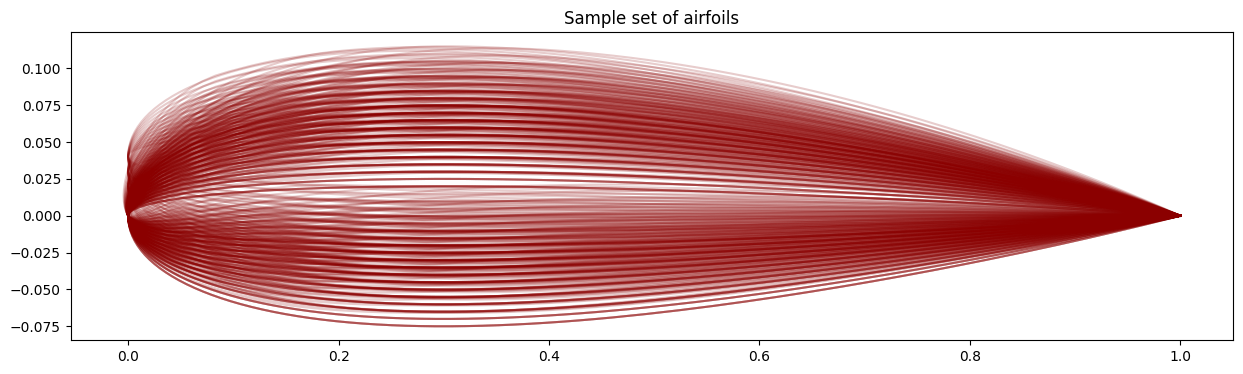

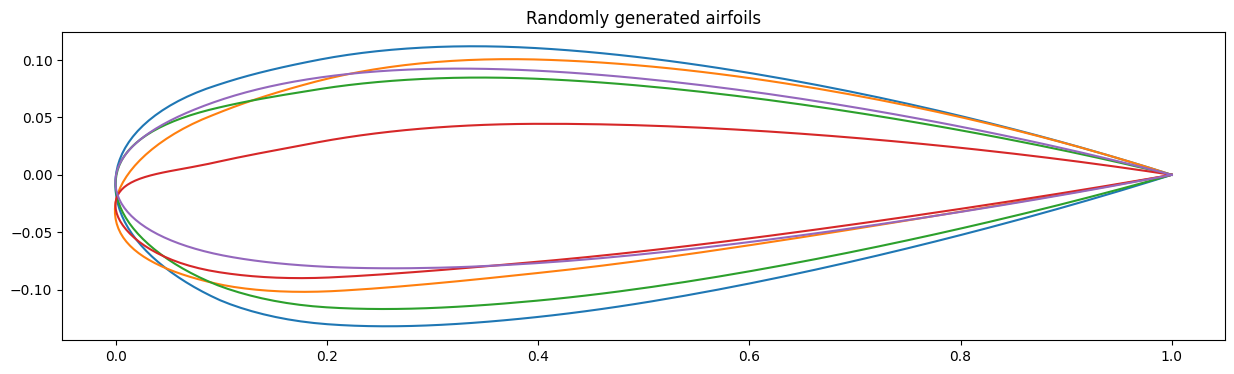

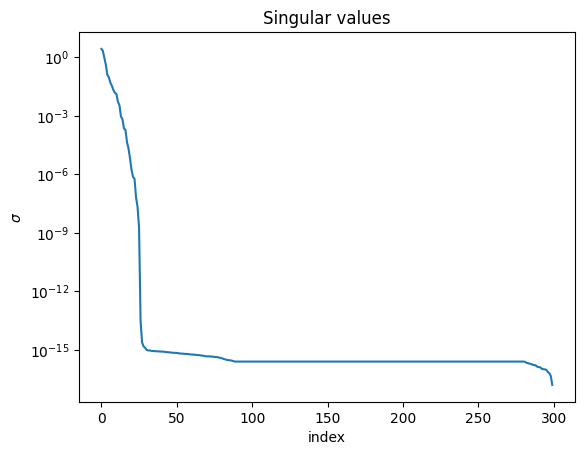

In [10]:
import numpy as np
import matplotlib.pylab as plt


def thickness_distribution(t, x):
    """Calculate the thickness distribution"""
    coeff = t / 0.2
    f = 0.2969 * np.sqrt(x)
    f += - 0.1260 * x
    f += - 0.3516 * x ** 2
    f +=   0.2843 * x ** 3
    f += - 0.1036 * x ** 4
    return coeff * f


def mean_camber_line_yc(m, p, X):
    """Calculate the mean camber line"""
    return np.array([
        (m / p ** 2) * ((2 * p * x) - x ** 2 ) if x < p
        else (m / (1 - p) ** 2) * (1 - (2 * p) + (2 * p * x) - x ** 2 ) for x in X
    ])


def dyc_dx(m, p, X):
    """derivative of mean camber line with respect to x"""
    return np.array([
        (2 * m / p ** 2) * (p - x) if x < p
        else (2 * m / (1 - p) ** 2) * (p - x) for x in X
    ])


def get_coordinates(naca, chord=1, n=100):
    # get airfoil characteristics
    t = chord * naca[2] / 100.0
    p = 10.0 * chord * naca[1] / 100.0
    m = chord * naca[0] / 100.0

    # values of x from 0 to the maximum chord (c)
    x = 0.5 * chord * (1.0 - np.cos(np.pi * np.linspace(0, 1, n)))

    # mean camber line (MCL) coordinates
    yc = mean_camber_line_yc(m, p, x)

    # calculate thickness distribution along length of airfoil
    yt = thickness_distribution(t, x)

    # derivative of mean camber line w.r.t x
    dyc = dyc_dx(m, p, x)

    # thickness needs to be applied perpendicular to the camber line
    theta = np.arctan(dyc)

    # determine final airfoil coordinates
    xu = x - yt * np.sin(theta)
    yu = yc + yt * np.cos(theta)
    xl = x + yt * np.sin(theta)
    yl = yc - yt * np.cos(theta)
    
    # Set the coordinates into a single vector
    coords = np.zeros(4 * n)
    coords[:2*n:2] = xu[::-1]
    coords[1:2*n:2] = yu[::-1]
    coords[2*n::2] = xl
    coords[2*n + 1::2] = yl

    return coords


def generate_airfoil_data():
    # Set bounds for the NACA airfoils
    max_camber = 4
    max_camber_loc = 4
    min_thickness = 4
    max_thickness = 15

    # Compute all of the coordinates
    coords = []
    for camber in range(0, max_camber + 1):
        for camber_loc in range(0, max_camber_loc + 1):
            for thickness in range(min_thickness, max_thickness + 1):
                naca = [camber, camber_loc, thickness]
                coords.append(get_coordinates(naca))

    # Convert the coordinates into a matrix
    X = np.array(coords).T

    return X

# Compute the airfoil data we're trying to fit
X = generate_airfoil_data()

# Compute the shape of the data
n = X.shape[0]
p = X.shape[1]

# Compute the mean value
Xmean = X.dot(np.ones(p)) / p
Xhat = X - np.outer(Xmean, np.ones(p))

# Compute the singular value decomposition
U, sigma, WT = np.linalg.svd(Xhat)
W = WT.T

# Create a random airfoils
ndim = 5
T = np.dot(Xhat, W[:, :ndim]) # Use the SVD result

# Extract the modes from the largest eigenvalues
# S = np.dot(Xhat.T, Xhat)
# eigs, WS = np.linalg.eigh(S)
# T = np.dot(Xhat, WS[:, -1:-ndim-1:-1])

# Plot all the airfoils
fig, ax = plt.subplots(figsize=(15, 4))
for i in range(p):
    plt.plot(X[::2, i], X[1::2, i], color="darkred", alpha=0.2)
plt.title("Sample set of airfoils")

# Create random vectors in the new coordinate space
v = 0.25 * np.random.uniform(size=(ndim, ndim))

# Plot the first three modes
fig, ax = plt.subplots(figsize=(15, 4))
for i in range(ndim):
    coords = Xmean + np.dot(T, v[i])
    plt.plot(coords[::2], coords[1::2])
plt.title("Randomly generated airfoils")

plt.figure()
plt.semilogy(np.arange(len(sigma)), sigma)
plt.title("Singular values")
plt.xlabel("index")
plt.ylabel(r"$\sigma$")

plt.show()

## Optimization Under Uncertainty

Uncertainty is always present in engineering analysis and design. The goal of uncertainty analysis is to quantify the effect of variability on the output based on variability of the input.

Most often, we're concerned with quantifying the expectation and variance or standard deviation of the output given some input uncertainty. We may want to also know the output distribution given the input distribution. 

In this course, however, we want to go beyond just uncertainty propagation to optimization under uncertainty: performing optimization with an analysis that includes modeled uncertainty. This field is called Optimization Under Uncertainty (OUU).

OUU includes *robust* design where the objective is less sensitive to changes in the input and *reliability* where the constraints are less likely to be violated due to changes in the input.

### Forward propagation of uncertainty

In the forward problem we want to propagate uncertainties through our system to the uncertainties in the output.

#### Monte Carlo

\begin{equation*}
\mathbb{E}(f) = \frac{1}{n} \sum_{i=1}^{n} f(x_i)
\end{equation*}

\begin{equation*}
\mathbb{V}(f) = \frac{1}{n - 1} \left( \left(\sum_{i=1}^{n} f(x_{i})^2\right) - n \mathbb{E}(f)^2\right)
\end{equation*}

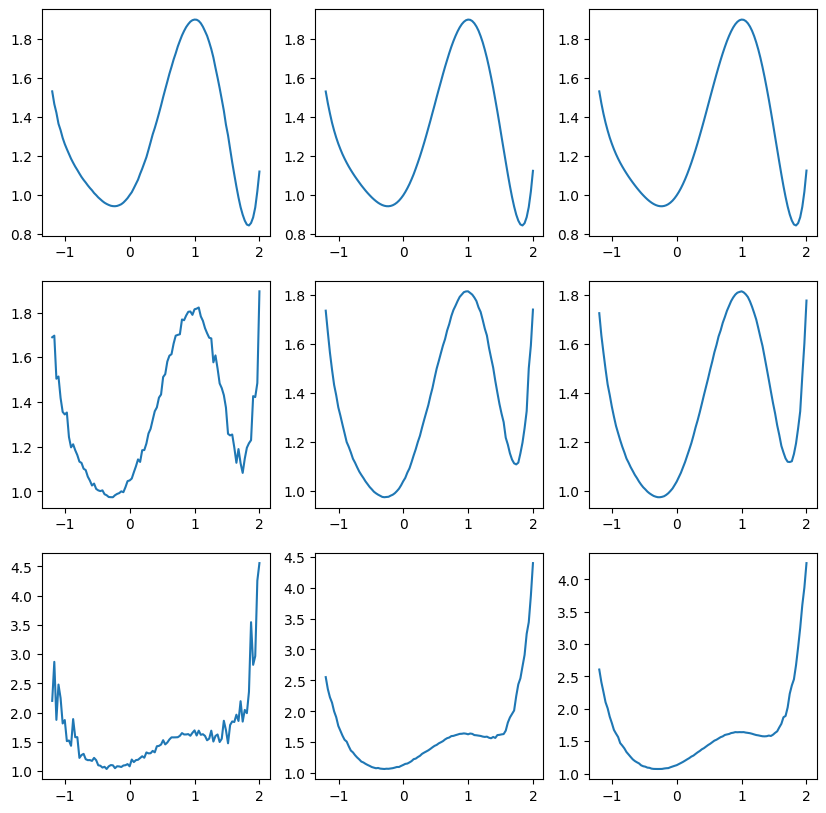

In [11]:
import numpy as np
import matplotlib.pylab as plt

def f(x):
    return np.exp(x/2) + 0.2 * x ** 6 - 0.2 * x ** 5 - 0.75 * x ** 4 + x ** 2

def monte_carlo(x, sigma=0.2, n=100):
    # Pull the samples from a normal distribution
    xrand = np.random.normal(loc=x, scale=sigma, size=n)

    # Evaluate the function
    fvals = f(xrand)

    # Compute the mean
    fmean = np.sum(fvals) / n

    # Compute the variance
    fvar = 1.0 / (n - 1) * (np.sum(fvals**2) - n * fmean ** 2)

    return fmean, fvar

def generate_data(sigma, n, m=100):
    x = np.linspace(-1.2, 2, m)
    fmean = np.zeros(m)
    fvar = np.zeros(m)

    for i in range(m):
        fmean[i], fvar[i] = monte_carlo(x[i], sigma=sigma, n=n)

    return x, fmean, fvar

sigma_list = [0.02, 0.2, 0.4]
nlist = [100, 5000, 20000]

fig, ax = plt.subplots(len(sigma_list), len(nlist), figsize=(10, 10))

for i, sigma in enumerate(sigma_list):
    for j, n in enumerate(nlist):
        x, fmean, fvar = generate_data(sigma, n)
        ax[i, j].plot(x, fmean)

plt.show()